In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_DIR = Path.cwd().parent

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

In [3]:
expression_filtered = pd.read_csv(
    PROCESSED_DIR / "expression_filtered.csv",
    index_col=0
)

clinical_matched = pd.read_csv(
    PROCESSED_DIR / "clinical_matched.csv",
    index_col=0
)

deg_results = pd.read_csv(
    PROCESSED_DIR / "DEG_results.csv"
)

In [4]:
tnbc_samples = clinical_matched[
    (clinical_matched["ER_Status_nature2012"] == "Negative") &
    (clinical_matched["PR_Status_nature2012"] == "Negative") &
    (clinical_matched["HER2_Final_Status_nature2012"] == "Negative")
].index

labels = pd.Series(
    "Non-TNBC",
    index=expression_filtered.columns
)

labels.loc[tnbc_samples] = "TNBC"

labels.value_counts()

Non-TNBC    621
TNBC        123
Name: count, dtype: int64

In [5]:
top50 = deg_results[
    deg_results["adj_pvalue"] < 0.05
].copy()

top50["abs_log2FC"] = top50["log2FoldChange"].abs()

top50 = top50.sort_values(
    "abs_log2FC",
    ascending=False
).head(50)

In [6]:
heatmap_data = expression_filtered.loc[top50["Gene"]]

heatmap_scaled = heatmap_data.sub(
    heatmap_data.mean(axis=1),
    axis=0
).div(
    heatmap_data.std(axis=1),
    axis=0
)

In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import seaborn as sns

In [9]:
column_colors = labels.map({
    "TNBC": "#d62728",
    "Non-TNBC": "#1f77b4"
})

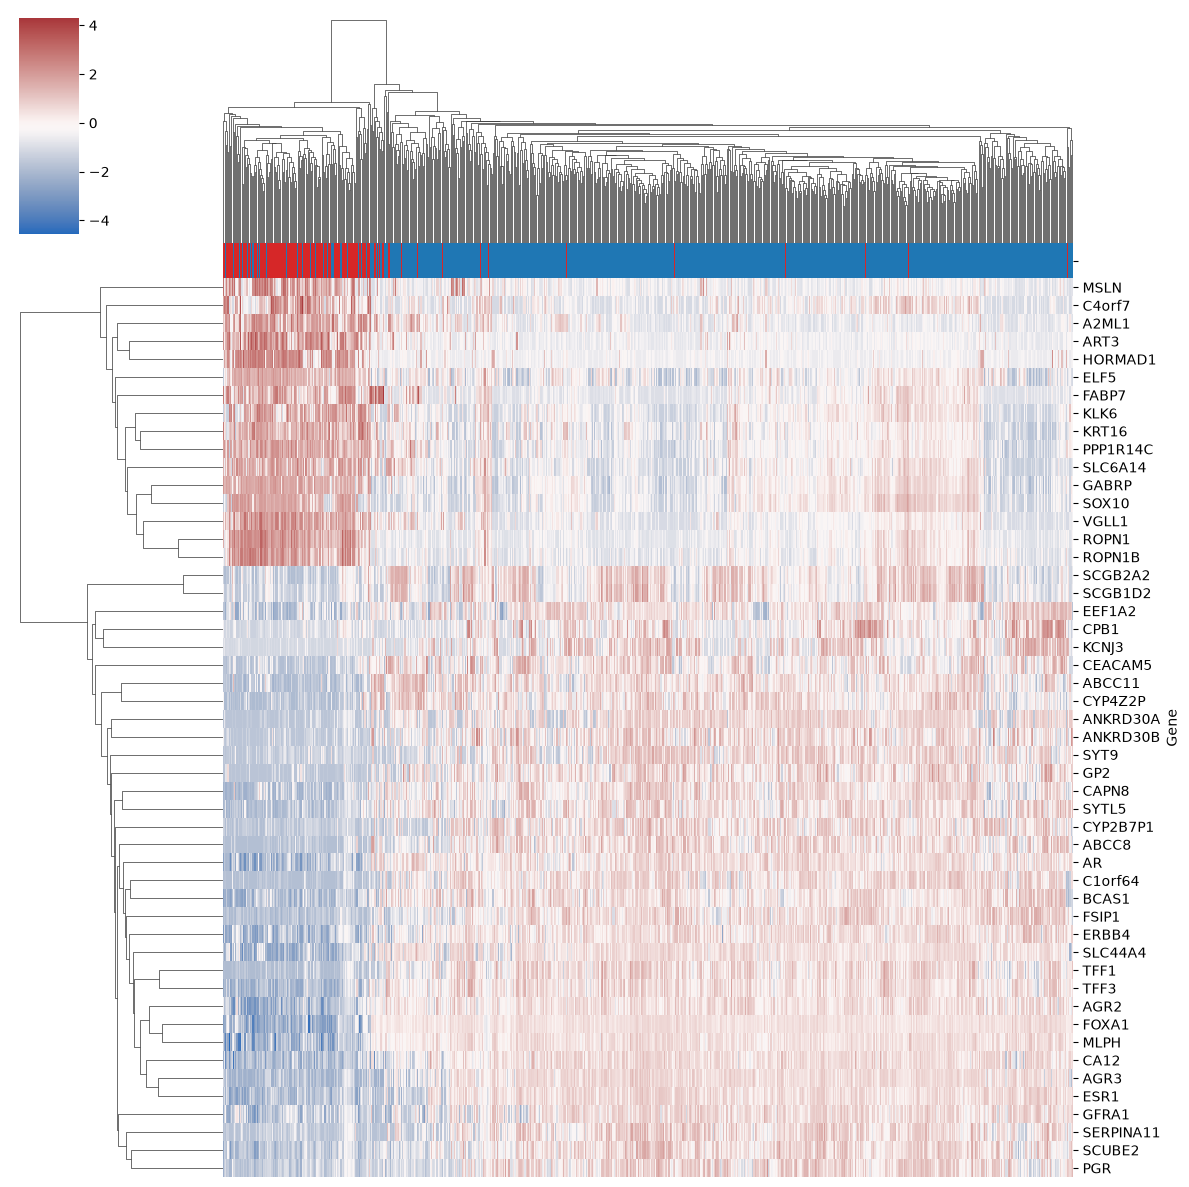

In [10]:
sns.clustermap(
    heatmap_scaled,
    cmap="vlag",
    row_cluster=True,
    col_cluster=True,
    xticklabels=False,
    yticklabels=True,
    col_colors=column_colors,
    figsize=(12,12)
)

plt.show()

In [11]:
pip install fastcluster

Note: you may need to restart the kernel to use updated packages.
